In [2]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import datetime
# === 1. PERSIAPAN DATASET & AUGMENTASI ===
train_dir = "intel-image-classification/seg_train/seg_train"
val_dir = "intel-image-classification/seg_test/seg_test"

train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=20, zoom_range=0.2, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(150, 150), batch_size=32, class_mode='categorical'
)
val_generator = val_datagen.flow_from_directory(
    val_dir, target_size=(150, 150), batch_size=32, class_mode='categorical'
)

Found 14034 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [3]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

# Kompilasi model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Training model
model.fit(train_generator, validation_data=val_generator, epochs=10)

# Simpan model
model.save('cnn_model.h5')

# Load label kelas
class_labels = list(train_generator.class_indices.keys())

c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.5048 - loss: 1.3424

c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


439/439 ━━━━━━━━━━━━━━━━━━━━ 181s 407ms/step - accuracy: 0.5049 - loss: 1.3419 - val_accuracy: 0.6570 - val_loss: 0.8950
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 162s 369ms/step - accuracy: 0.6637 - loss: 0.9030 - val_accuracy: 0.7457 - val_loss: 0.6864
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 174s 395ms/step - accuracy: 0.6914 - loss: 0.8420 - val_accuracy: 0.7627 - val_loss: 0.6737
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 164s 373ms/step - accuracy: 0.7171 - loss: 0.7883 - val_accuracy: 0.7907 - val_loss: 0.5964
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 162s 368ms/step - accuracy: 0.7516 - loss: 0.7091 - val_accuracy: 0.8067 - val_loss: 0.5398
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 161s 367ms/step - accuracy: 0.7497 - loss: 0.7008 - val_accuracy: 0.7913 - val_loss: 0.6031
Epoch 7/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 161s 368ms/step - accuracy: 0.7582 - loss: 0.6747 - val_accuracy: 0.8040 - val_loss: 0.5398
Epoch 8/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 161s 366ms/step - accuracy: 0.7592 - loss: 0.66

In [9]:
def analyze_light_spectrum(image):
    """Menganalisis spektrum cahaya berdasarkan luminance."""
    # Konversi ke YUV untuk mendapatkan luminance (Y channel)
    yuv = cv2.cvtColor(image, cv2.COLOR_BGR2YUV)
    luminance = yuv[:, :, 0]
    avg_luminance = np.mean(luminance)
    
    # Menampilkan histogram luminance
    plt.figure(figsize=(7, 5))
    
   # Histogram Luminance (Y channel)
    hist_y = cv2.calcHist([luminance], [0], None, [300], [0, 300])
    plt.plot(hist_y, color='black')
    plt.title(f"Luminance Histogram\nBrightness: {avg_luminance:.2f}")
    plt.xlabel("Intensitas Luminance")
    plt.ylabel("Jumlah Piksel")
    
    plt.subplots_adjust(bottom=0.2)

    # Menampilkan waktu
    current_time = datetime.datetime.now().strftime("%d-%m-%Y %H:%M:%S")
    plt.figtext(0.02, 0.01, f"Generated on: {current_time}", 
            fontsize=10, style='italic', color='black', ha='left')
    
    plt.show()
    
    # Menentukan kategori pencahayaan berdasarkan luminance
    if avg_luminance < 50:
        return f"Gelap"
    elif 50 <= avg_luminance < 150:
        return f"Cahaya Sedang"
    else:
        return f"Terang"

 # Load model CNN yang sudah dilatih
model = load_model('cnn_model.h5')
 # Load label kelas
class_labels = list(train_generator.class_indices.keys())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


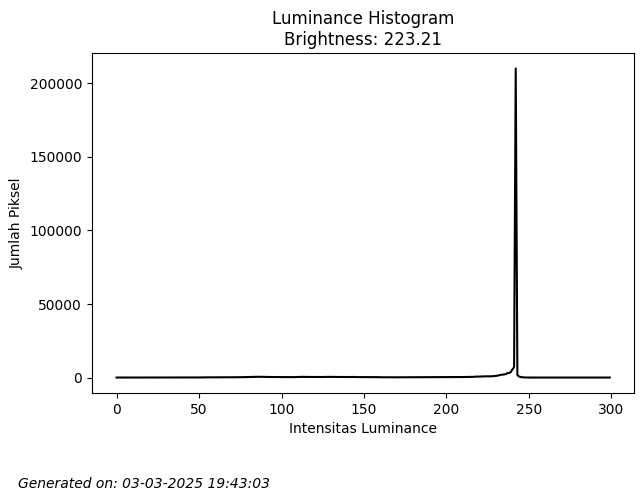

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


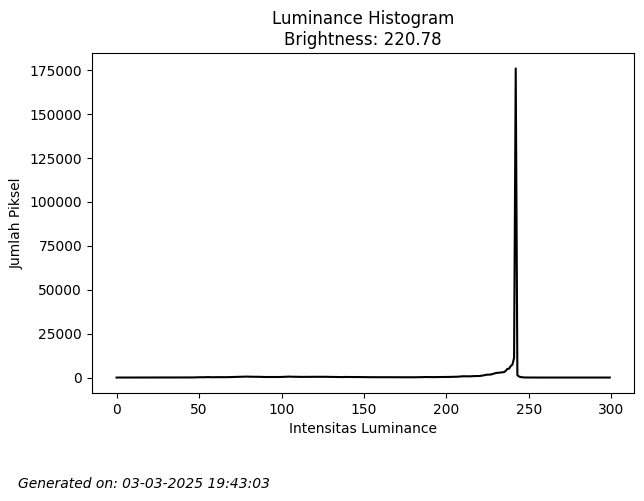

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


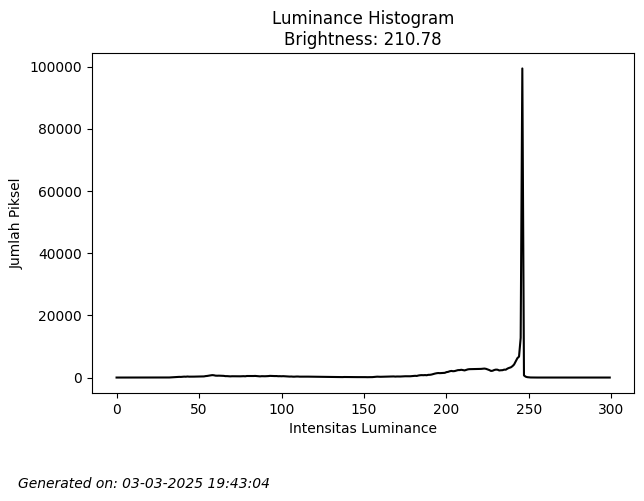

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


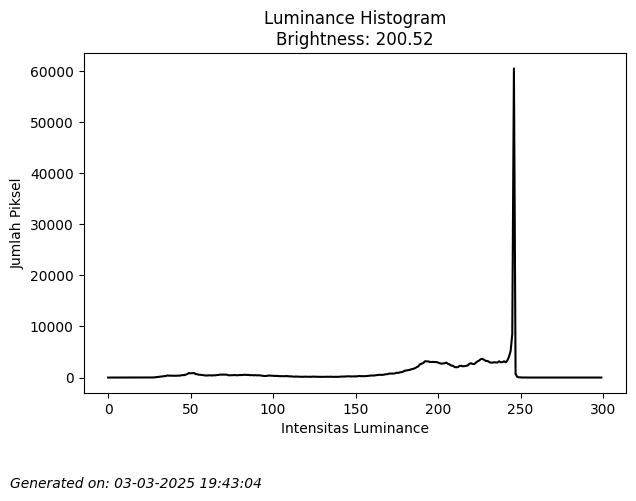

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


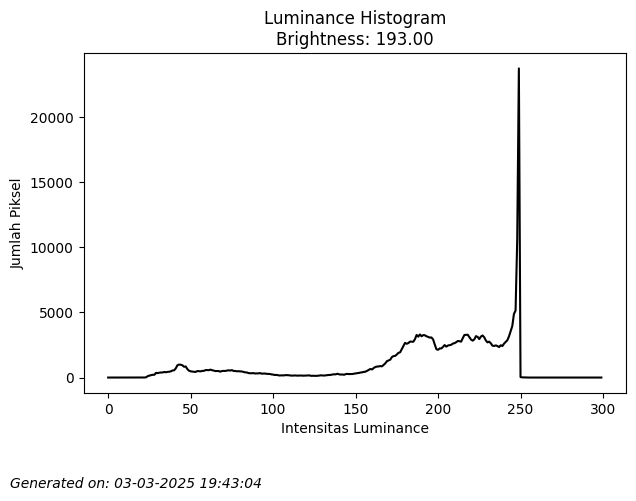

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


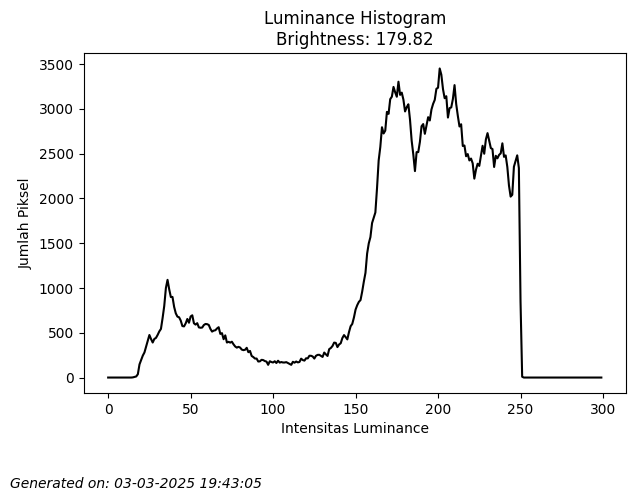

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


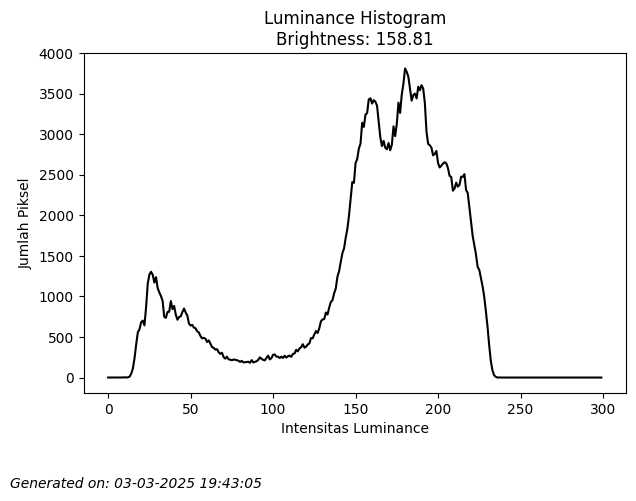

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


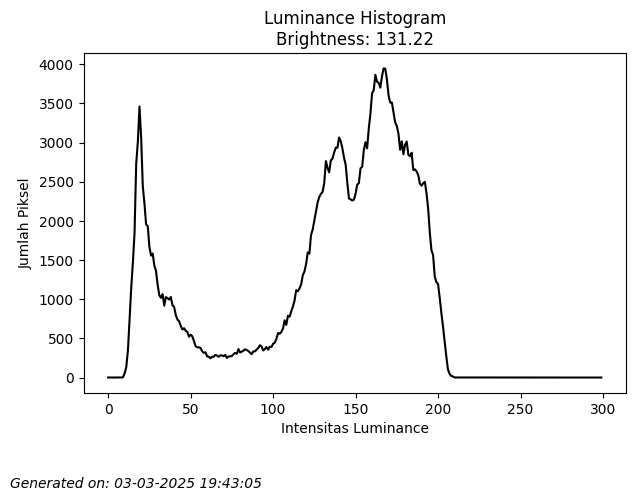

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


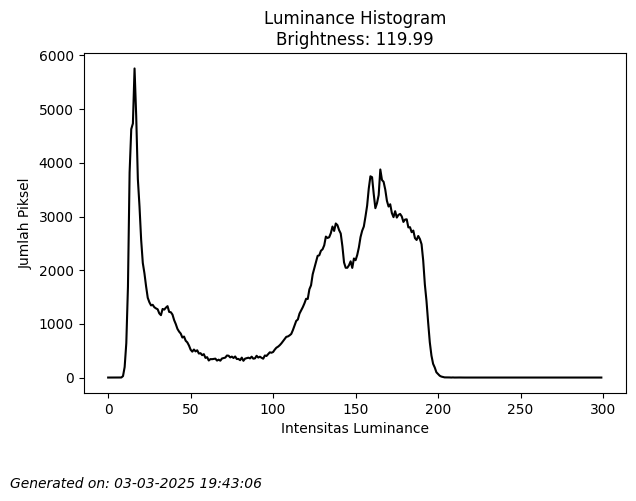

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


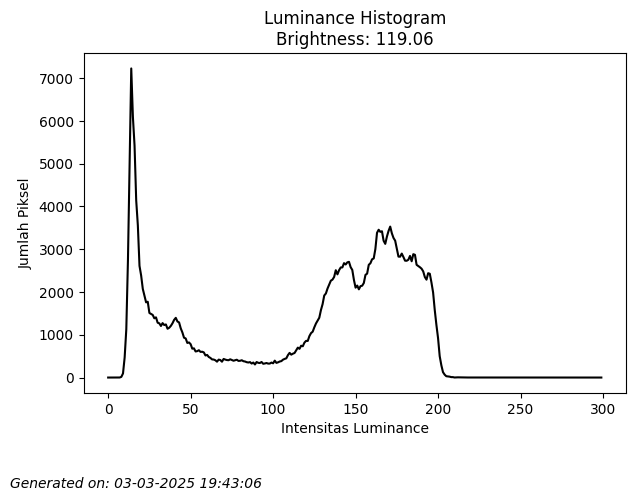

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


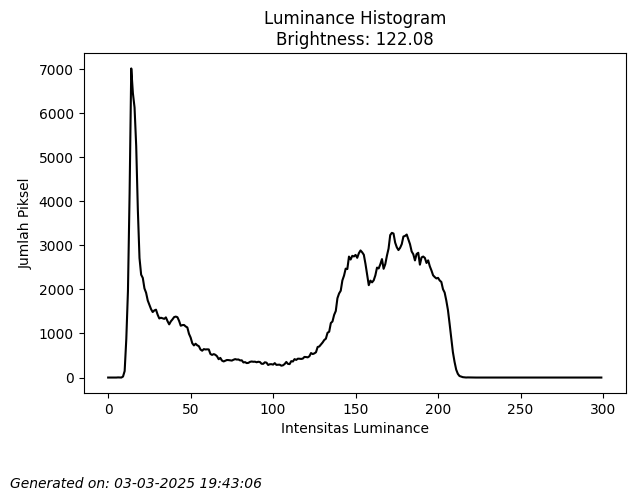

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


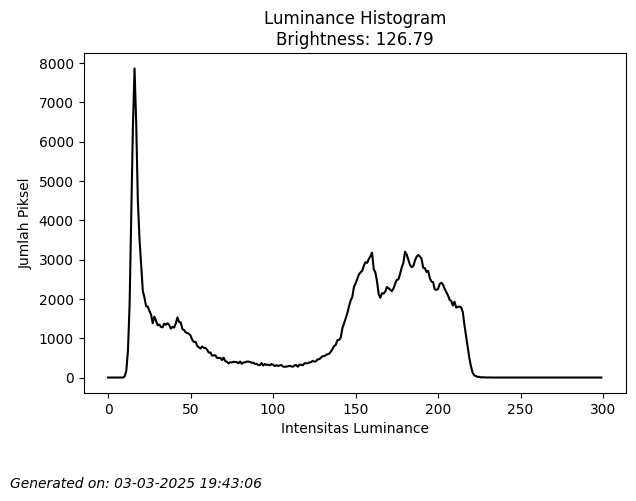

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


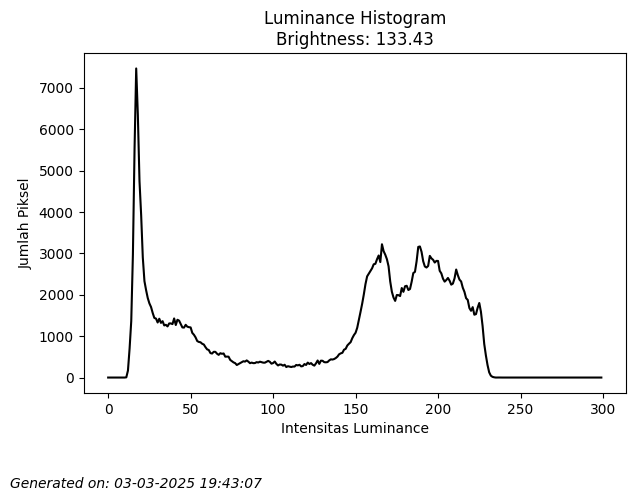

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


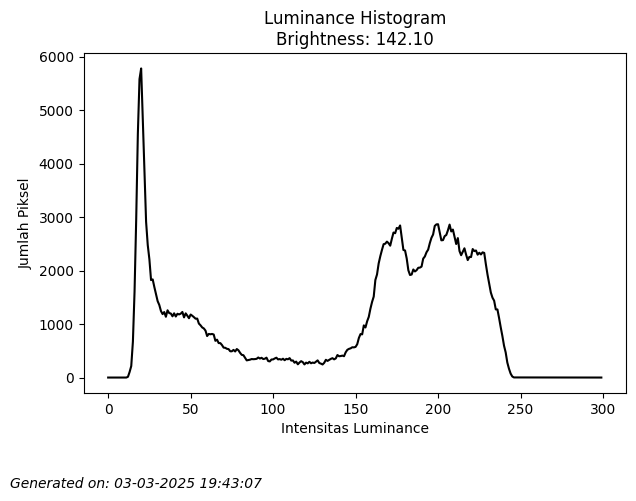

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


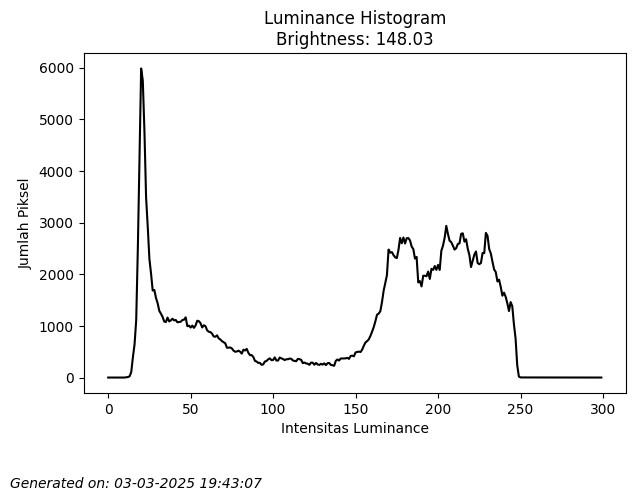

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


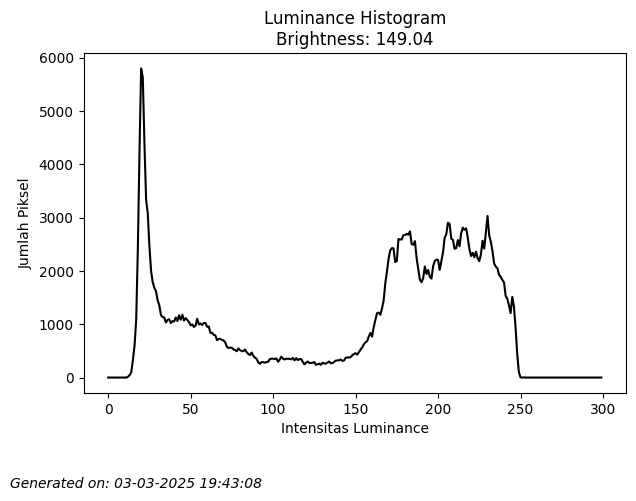

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


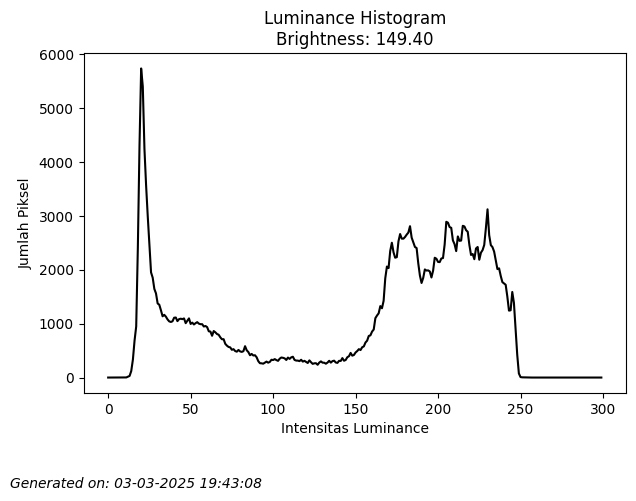

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


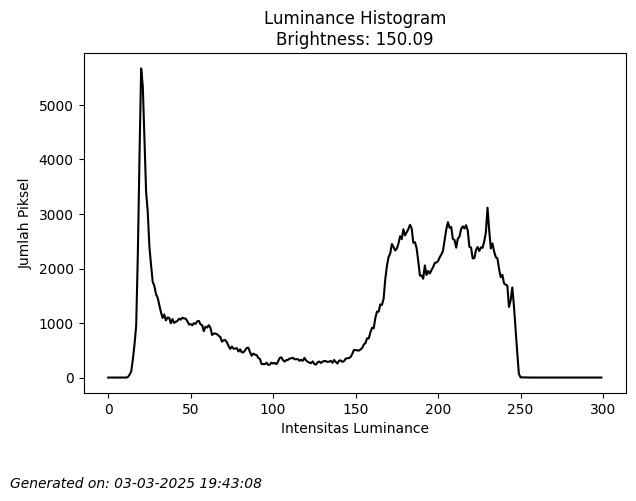

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


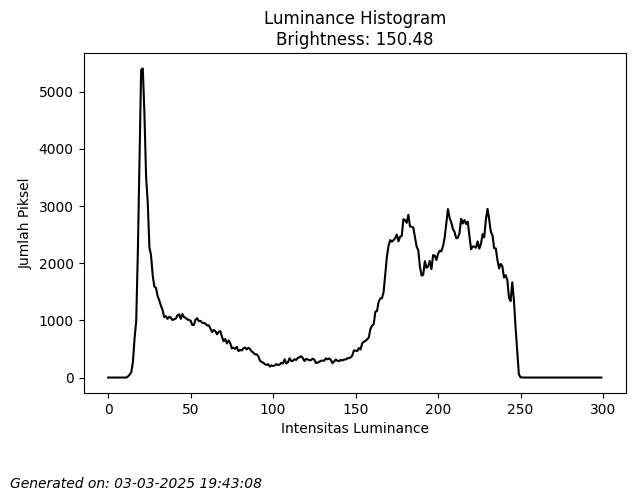

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


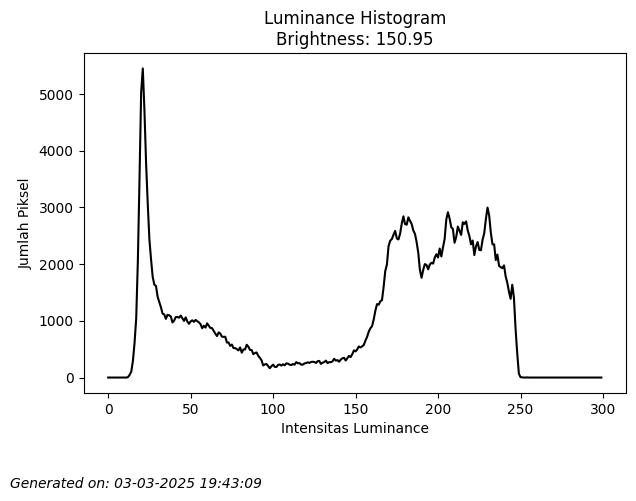

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


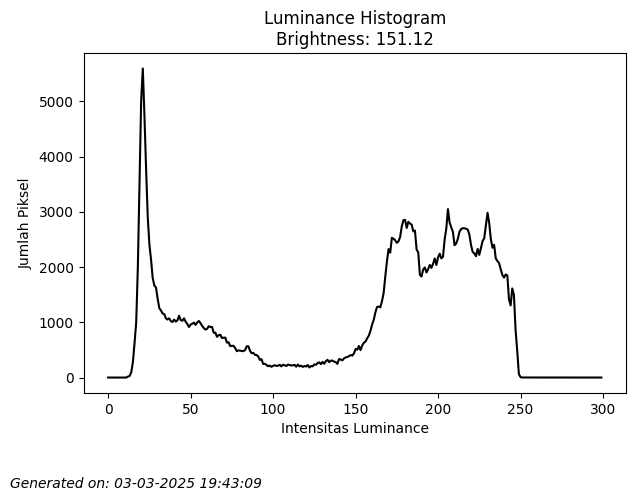

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


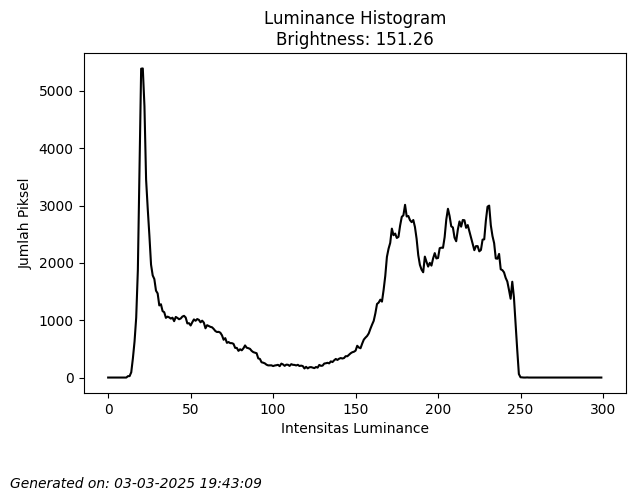

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


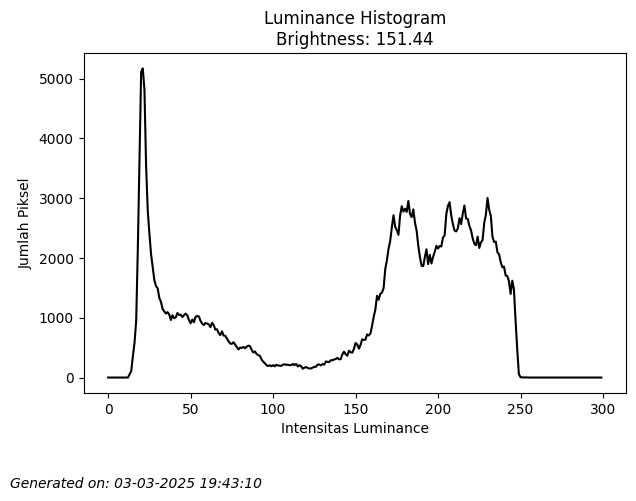

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


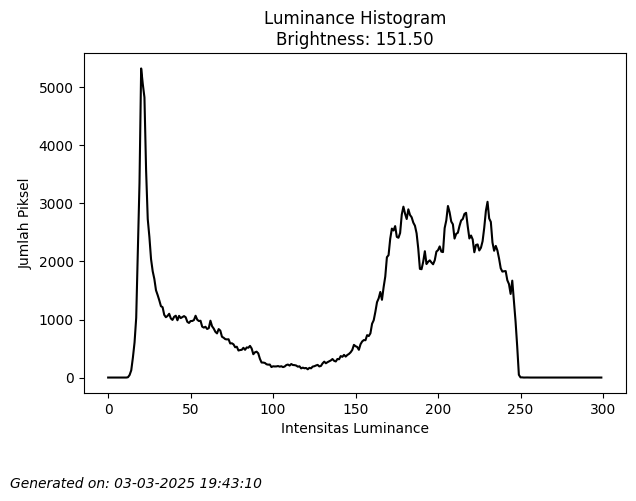

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


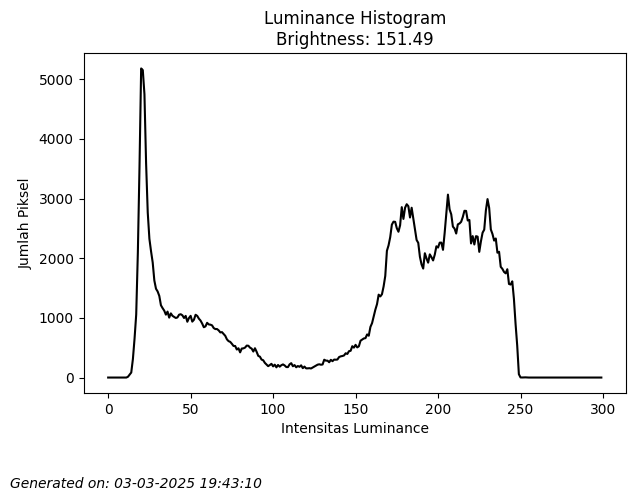

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


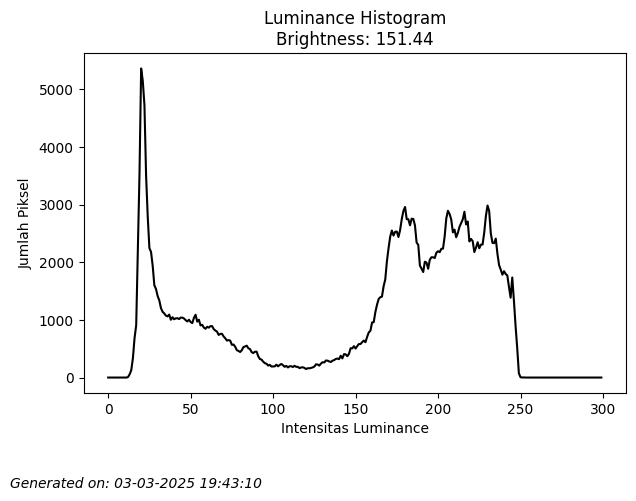

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


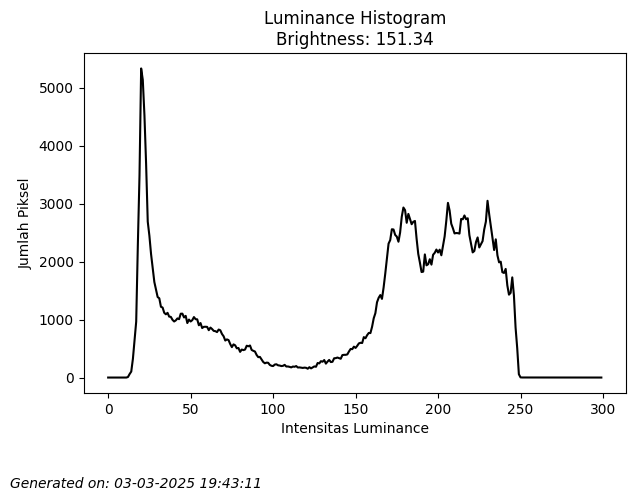

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


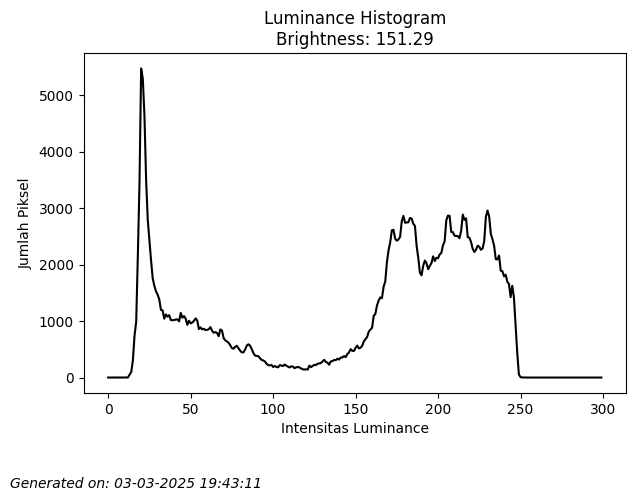

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


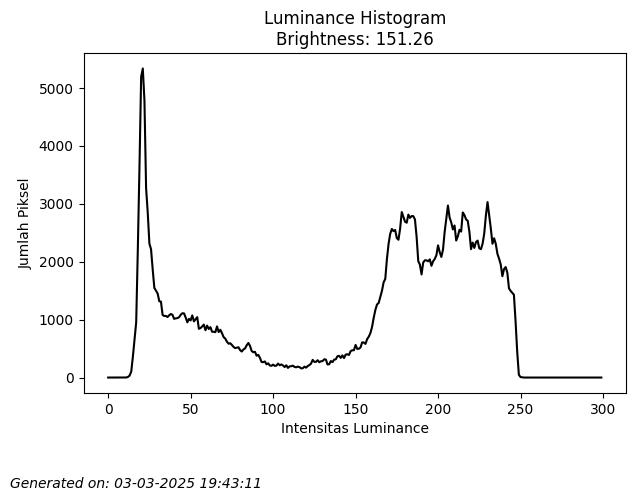

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


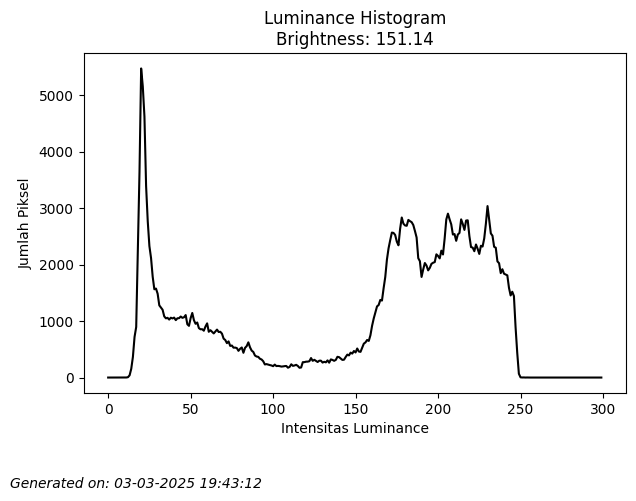

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


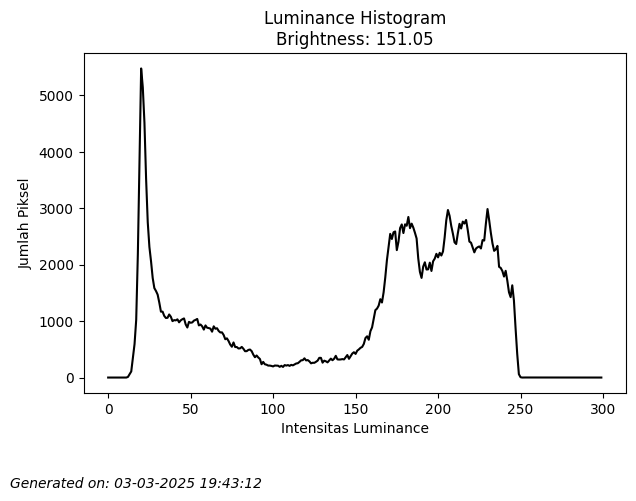

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


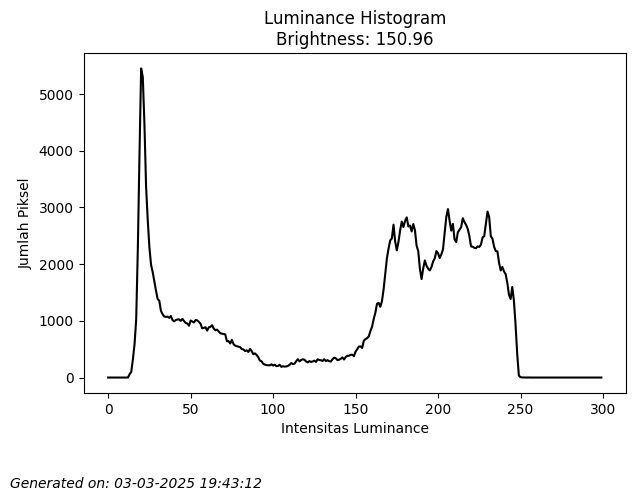

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


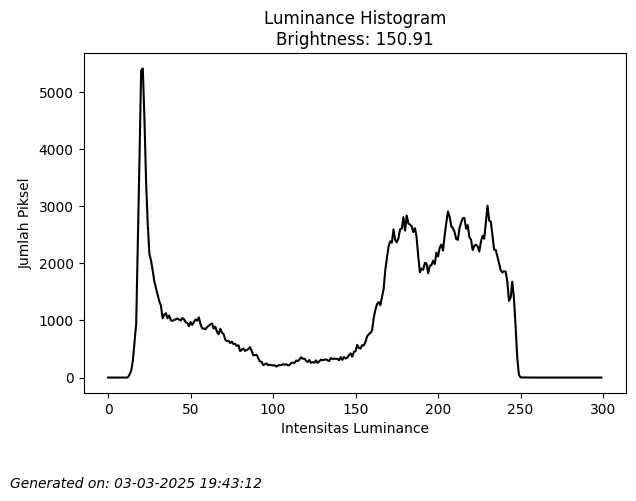

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


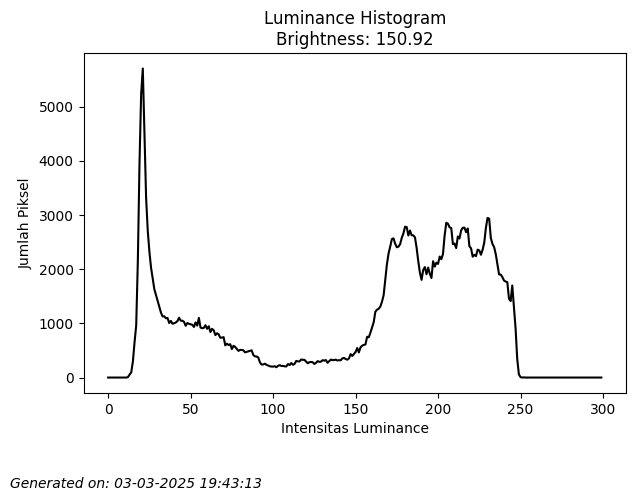

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


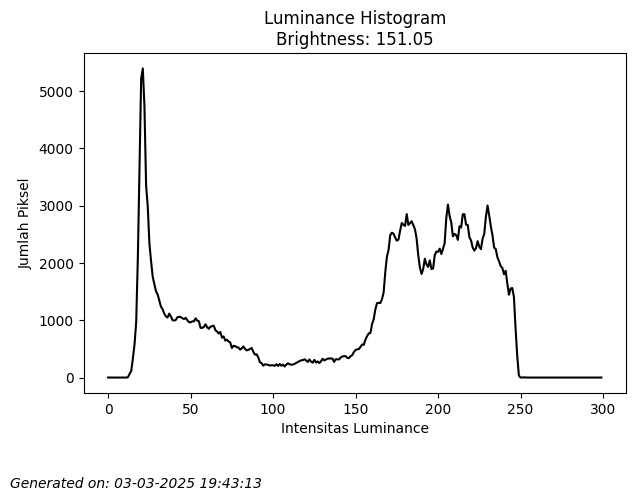

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


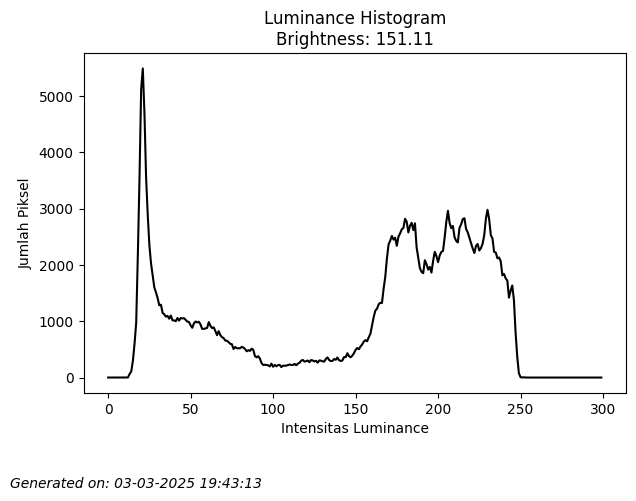

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


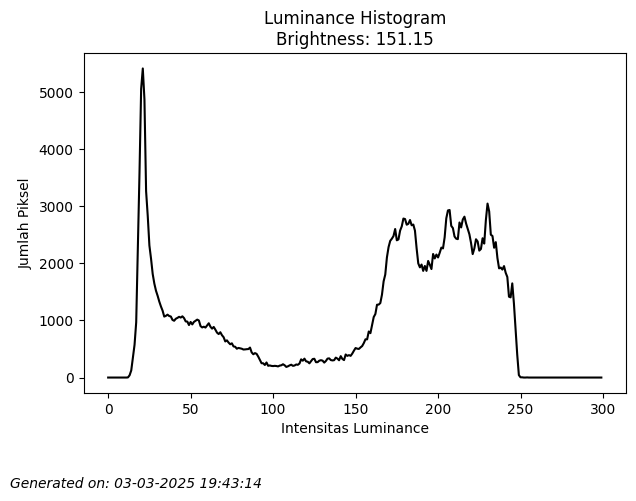

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


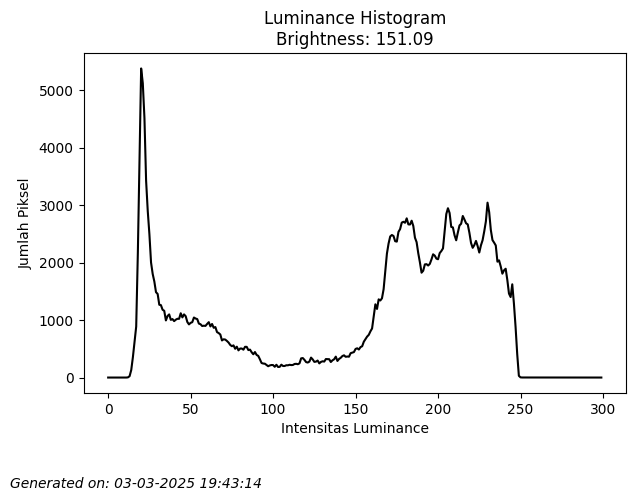

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


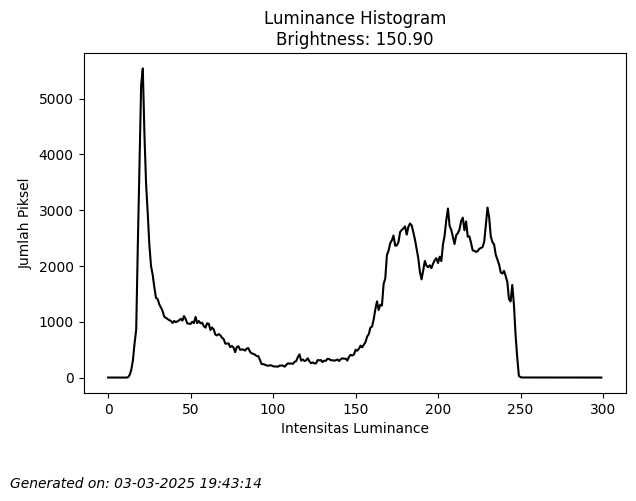

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


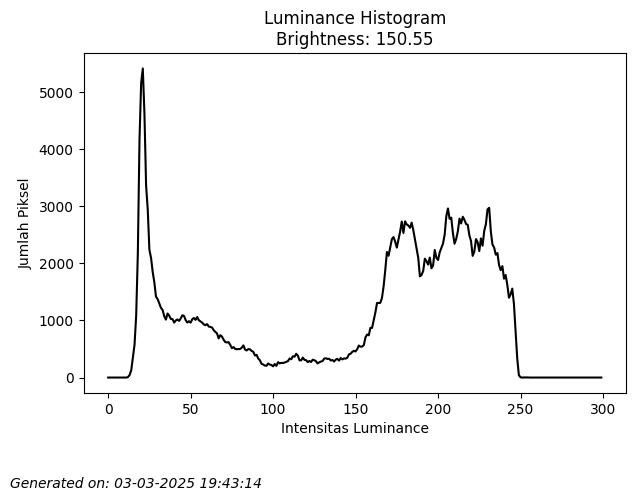

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


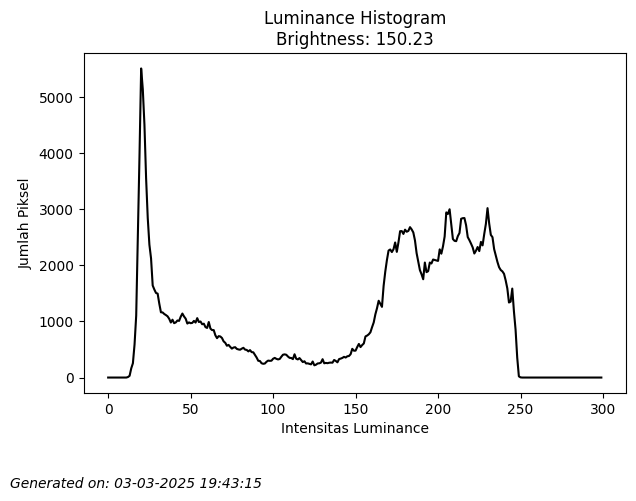

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


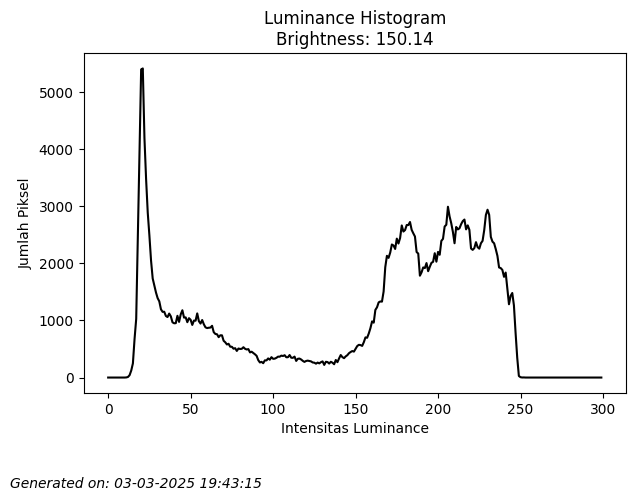

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


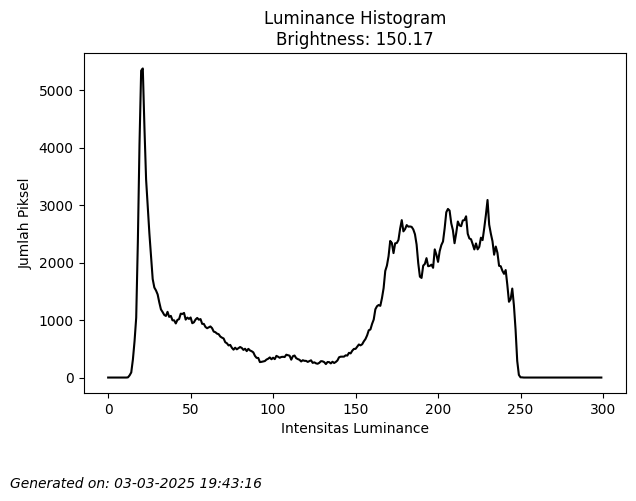

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


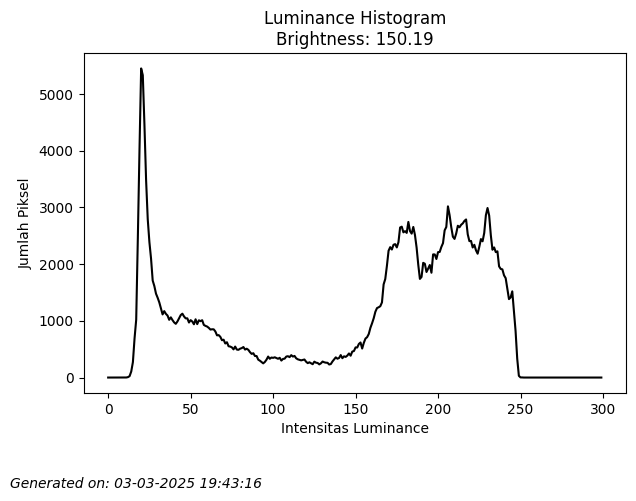

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


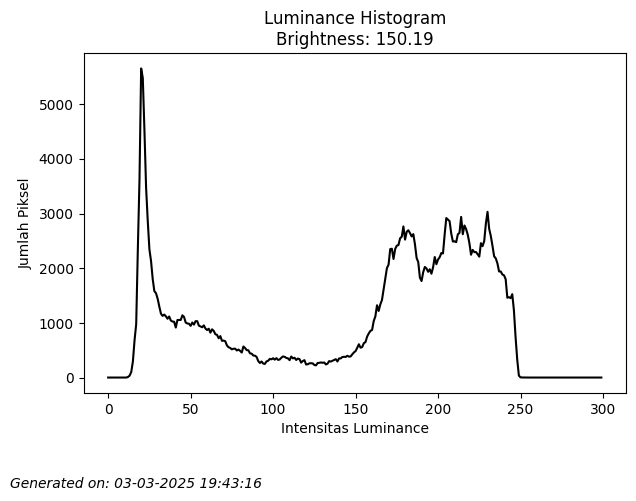

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


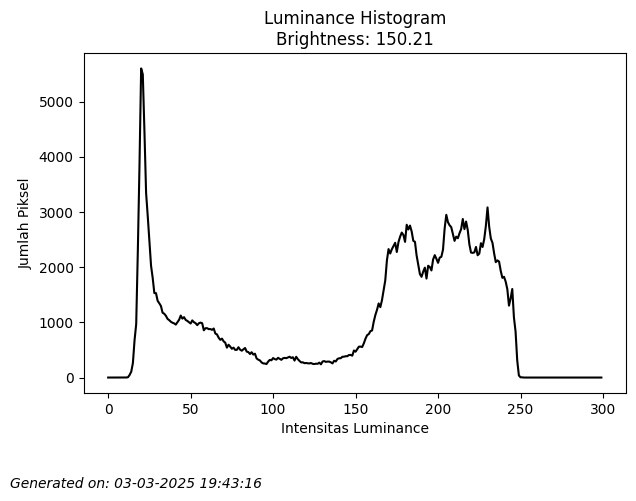

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


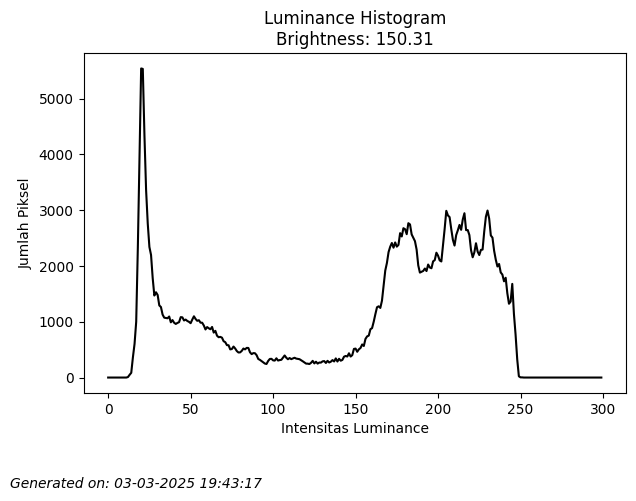

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


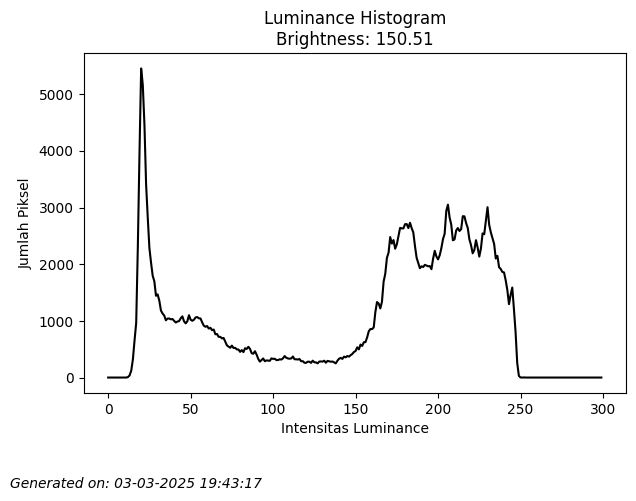

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


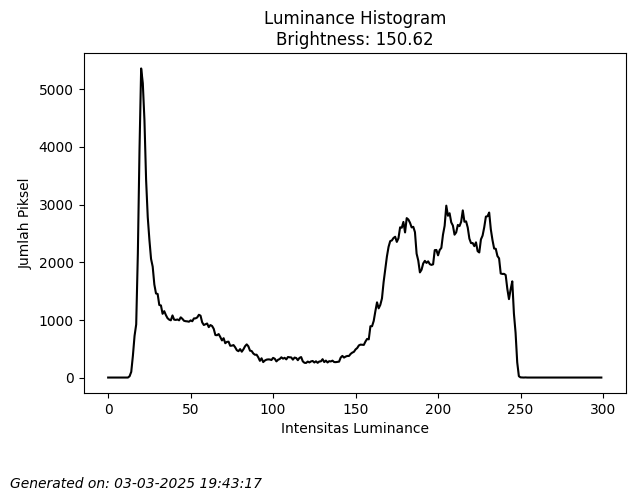

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


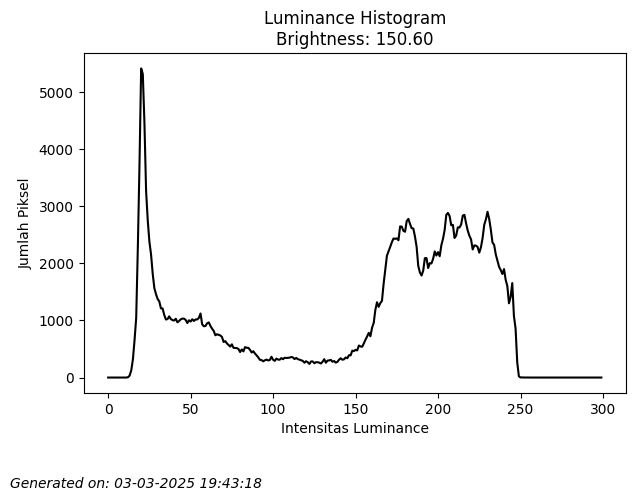

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


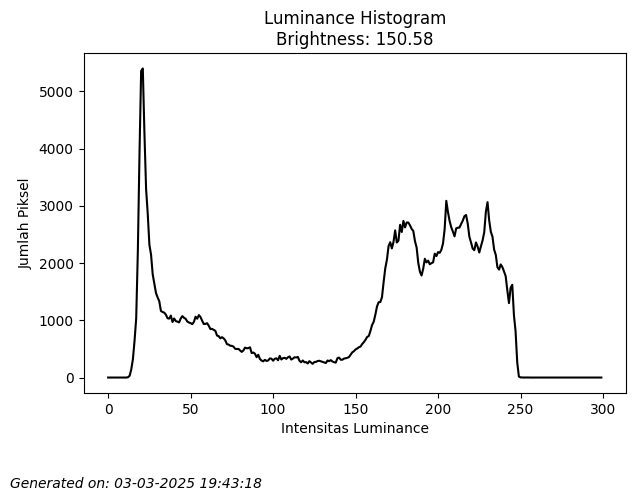

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


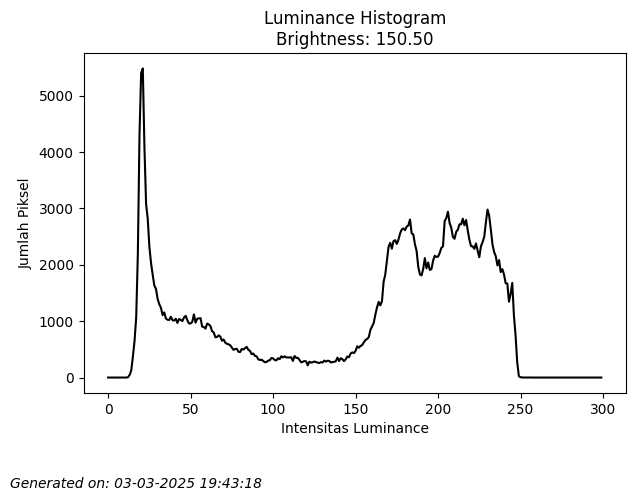

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


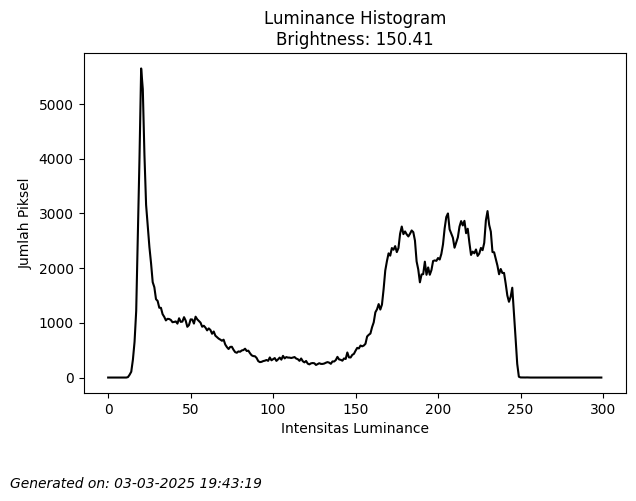

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


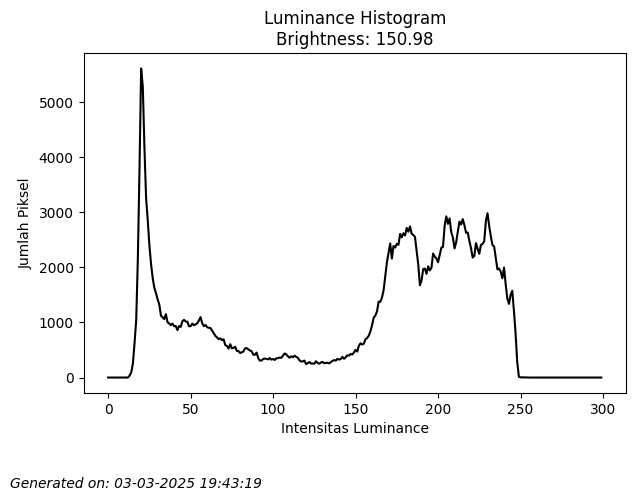

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


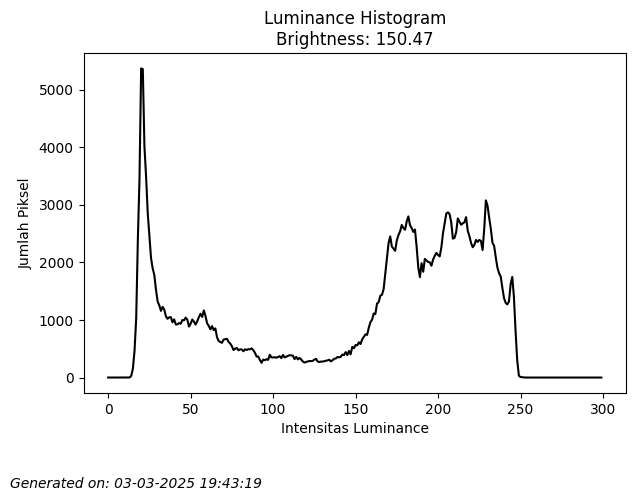

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


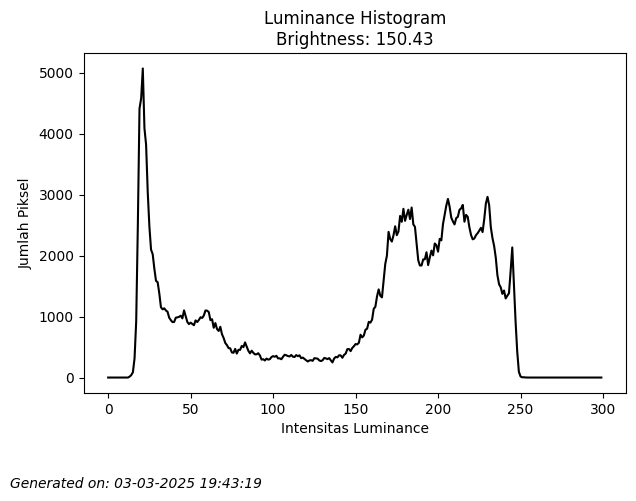

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


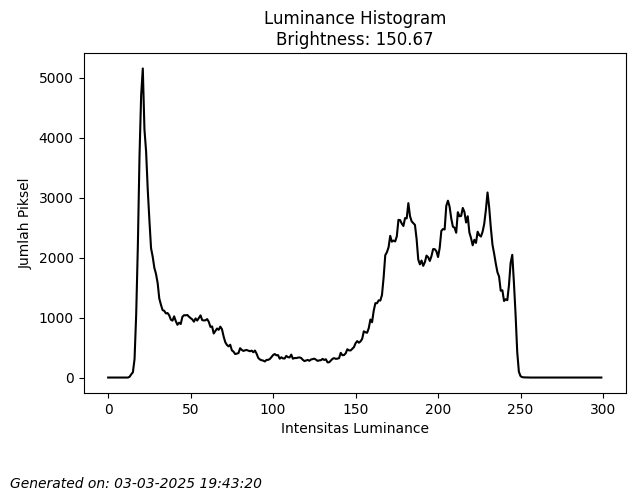

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


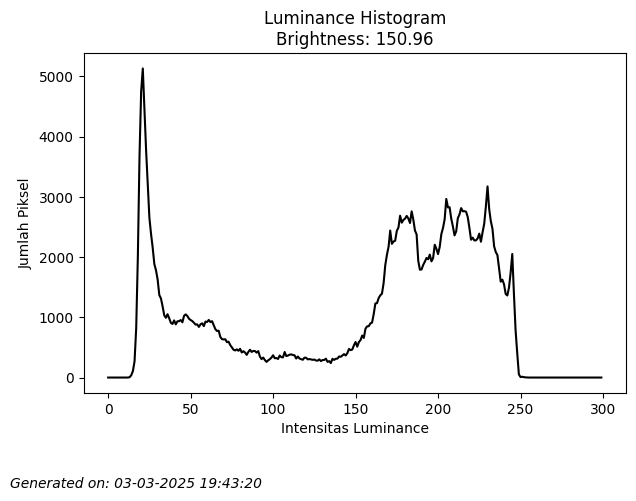

In [29]:
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    # Mode Night Vision (Gray + Colormap JET)
    night_vision = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    night_vision = cv2.applyColorMap(night_vision, cv2.COLORMAP_JET)

    # Preprocessing gambar
    img = cv2.resize(frame, (150, 150))
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)

    # Prediksi kelas
    pred = model.predict(img)
    label = class_labels[np.argmax(pred)]

    # Analisis spektrum cahaya
    light_status = analyze_light_spectrum(frame)

    # Menampilkan waktu secara real-time
    current_time = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    # Menampilkan hasil di frame
    cv2.putText(frame, f'Class: {label}', (20, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)
    cv2.putText(frame, light_status, (450, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)
    cv2.putText(frame, f'Time: {current_time}', (400, 450), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2)
    
    cv2.imshow('Frame', frame)
    cv2.imshow('Night Vision', night_vision)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

In [3]:
pip install scipy

     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ------------- -------------------------- 20.5/60.8 kB ? eta -:--:--
     -------------------------------- ----- 51.2/60.8 kB 871.5 kB/s eta 0:00:01
     -------------------------------------- 60.8/60.8 kB 537.5 kB/s eta 0:00:00
   ---------------------------------------- 0.0/41.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.2 MB 2.0 MB/s eta 0:00:21
   ---------------------------------------- 0.1/41.2 MB 1.1 MB/s eta 0:00:40
   ---------------------------------------- 0.1/41.2 MB 1.0 MB/s eta 0:00:40
   ---------------------------------------- 0.1/41.2 MB 950.9 kB/s eta 0:00:44
   ---------------------------------------- 0.2/41.2 MB 654.6 kB/s eta 0:01:03
   ---------------------------------------- 0.2/41.2 MB 654.6 kB/s eta 0:01:03
   ---------------------------------------- 0.3/41.2 MB 862.0 kB/s eta 0:00:48
   ---


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
